# Plot trace element concentrations

Author: **Niels J. de Winter** (*n.j.de.winter@vu.nl*)<br>
Assistant Professor Vrije Universiteit Amsterdam

In [12]:
# Load necessary libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from scipy import signal

### Read data from all specimens

In [3]:
# Load all files from the folder
folder_path = "TE_data_with_GR_T_S/"
all_data = pd.DataFrame()
for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        # Read each file
        file_data = pd.read_csv(
            os.path.join(folder_path, file),
            dtype={ # Convert mixed columns to object type
                'T_timing_1': "a",
                'T_timing_2': "a",
                'T_timing_3': "a",
                'T_timing_4': "a",
                'T_std_timing_1': "a",
                'T_std_timing_2': "a",
                'T_std_timing_3': "a",
                'T_std_timing_4': "a",
                'S_timing_1' : "a",
                'S_timing_2' : "a",
                'S_timing_3' : "a",
                'S_timing_4' : "a",
                'S_std_timing_1': "a",
                'S_std_timing_2': "a",
                'S_std_timing_3': "a",
                'S_std_timing_4': "a"
            },
            index_col=False
        )
        # Print names of all columns in the current file
        # print(f"Columns in {file}: {file_data.columns.tolist()}")
        # Add a column for the specimen name
        file_data['specimen'] = file.split('_')[0]  # Specimen name is the first part of the filename
        # Add column for species based on the specimen name
        file_data['species'] = 'Cerastoderma edule' if file.split('_')[0] != 'B255' else 'Ruditapes philippinarum'
        # Add column separating subtidal vs intertidal treatments
        file_data['treatment'] = 'intertidal' if file.split('_')[1] == 'int' else 'subtidal' if file.split('_')[1] == 'sub' else 'unknown'
        # Concatenate into a single DataFrame
        all_data = pd.concat([all_data, file_data], ignore_index=True)

# For the element columns, replace all zero values with NaN to avoid skewing the analysis
element_columns = ['23Na/43Ca', '25Mg/43Ca', '43Ca/43Ca', '55Mn/43Ca', '88Sr/43Ca', '138Ba/43Ca']
all_data[element_columns] = all_data[element_columns].replace(0, np.nan)

# Remove all unnamed columns
all_data = all_data.loc[:, ~all_data.columns.str.contains('^Unnamed')]
print(all_data.dtypes) # print dtypes of all columns

# Display the first few rows of the combined data
all_data.head()

depth             float64
proxy_filtered    float64
time              float64
Xpos              float64
Ypos              float64
                   ...   
S_std_timing_4     object
Chl_timing_4      float64
specimen           object
species            object
treatment          object
Length: 67, dtype: object


,depth,proxy_filtered,time,Xpos,Ypos,Ca43,23Na/43Ca,25Mg/43Ca,43Ca/43Ca,55Mn/43Ca,...,S_std_timing_3,Chl_timing_3,T_timing_4,T_std_timing_4,S_timing_4,S_std_timing_4,Chl_timing_4,specimen,species,treatment
0,0.445779,0.013676,62.33211,30944.10620,80703.27530,6301.588000,199.059248,1.253571,1000.0,0.306491,...,0.03,2.087,5.843,0.008,25.485,0.03,2.087,B255,Ruditapes philippinarum,intertidal
1,0.891558,0.000000,62.44125,30944.46978,80703.01737,5301.123838,235.482235,3.406310,1000.0,0.347474,...,0.03,2.087,5.843,0.008,25.485,0.03,2.087,B255,Ruditapes philippinarum,intertidal
2,1.337336,0.019326,62.55040,30944.83337,80702.75945,4600.846556,284.331679,1.771388,1000.0,0.380053,...,0.03,2.087,5.843,0.008,25.485,0.03,2.087,B255,Ruditapes philippinarum,intertidal
3,1.783115,0.037763,62.65955,30945.19695,80702.50152,5751.322804,221.307763,3.115197,1000.0,0.348871,...,0.03,2.087,5.843,0.008,25.485,0.03,2.087,B255,Ruditapes philippinarum,intertidal
4,2.228894,0.013795,62.76871,30945.56053,80702.24359,6251.562891,205.558351,1.264443,1000.0,0.242893,...,0.03,2.087,5.843,0.008,25.485,0.03,2.087,B255,Ruditapes philippinarum,intertidal


### Clean combined dataframe

## Plot all elemental records against depth, organized by treatment and species

<>:49: SyntaxWarning: invalid escape sequence '\i'
<>:50: SyntaxWarning: invalid escape sequence '\i'
<>:51: SyntaxWarning: invalid escape sequence '\i'
<>:49: SyntaxWarning: invalid escape sequence '\i'
<>:50: SyntaxWarning: invalid escape sequence '\i'
<>:51: SyntaxWarning: invalid escape sequence '\i'
C:\Users\nwi213\AppData\Local\Temp\ipykernel_25000\3945648289.py:49: SyntaxWarning: invalid escape sequence '\i'
  axs[0, 0].set_ylabel('$\it{Cerastoderma}$ $\it{edule}$\nintertidal\nMolar fraction (%)', labelpad = 0)
C:\Users\nwi213\AppData\Local\Temp\ipykernel_25000\3945648289.py:50: SyntaxWarning: invalid escape sequence '\i'
  axs[1, 0].set_ylabel('$\it{Cerastoderma}$ $\it{edule}$\nsubtidal\nMolar fraction (%)', labelpad = 0)
C:\Users\nwi213\AppData\Local\Temp\ipykernel_25000\3945648289.py:51: SyntaxWarning: invalid escape sequence '\i'
  axs[2, 0].set_ylabel('$\it{Ruditapes}$ $\it{philippinarum}$\nintertidal\nMolar fraction (%)', labelpad = 0)


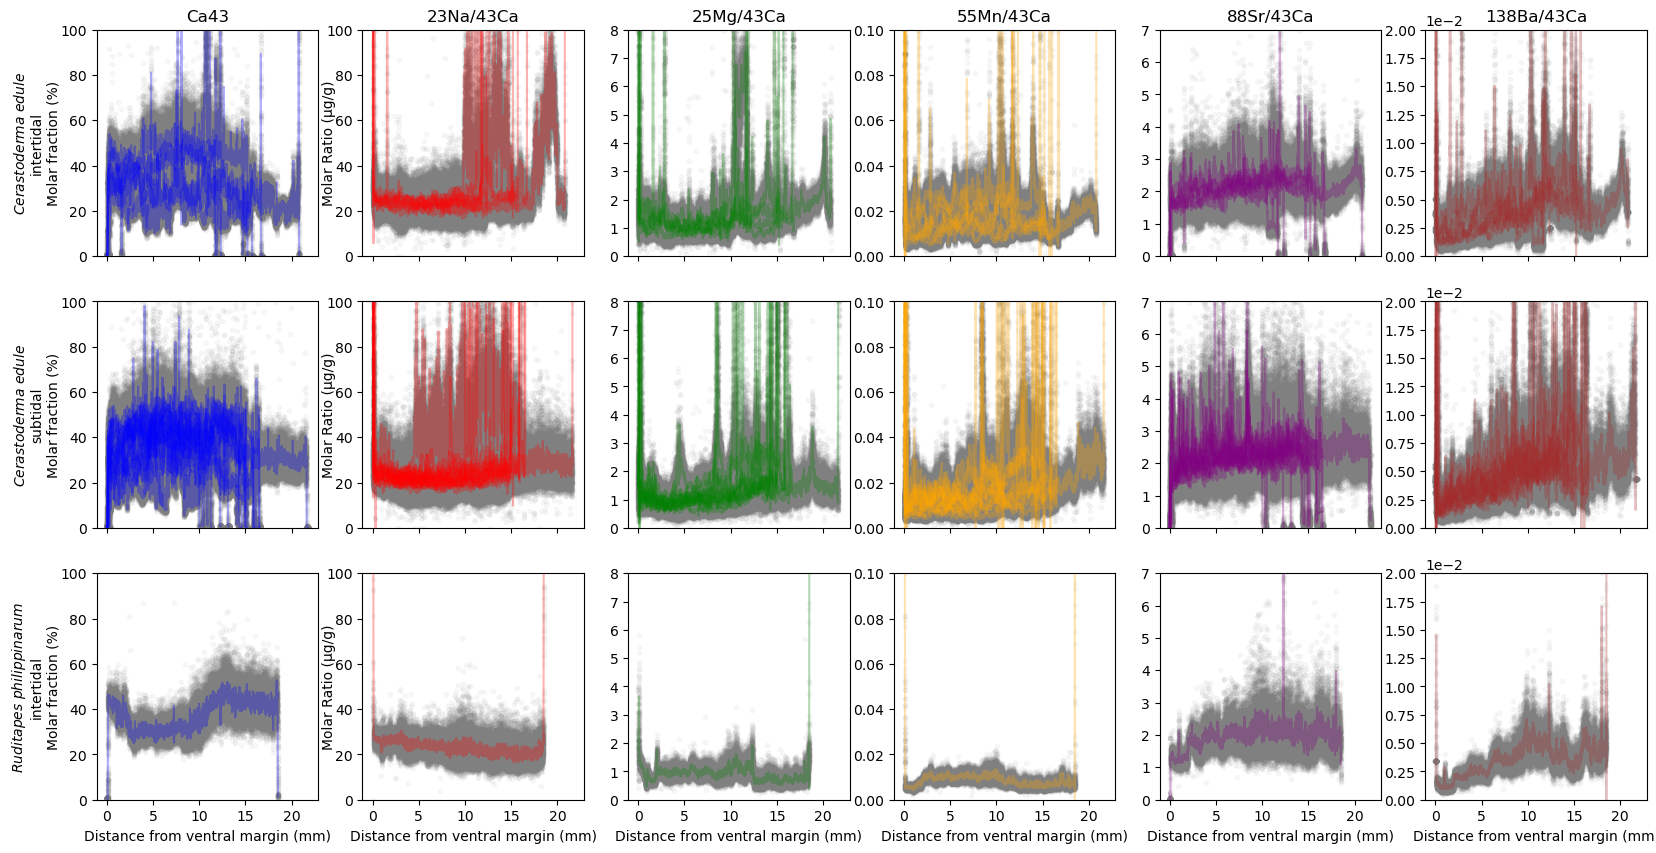

In [35]:
# Prepare titles and axis values for the plots
element_columns = ['Ca43', '23Na/43Ca', '25Mg/43Ca', '55Mn/43Ca', '88Sr/43Ca', '138Ba/43Ca']
element_colors = {
    'Ca43': 'blue',
    '23Na/43Ca': 'red',
    '25Mg/43Ca': 'green',
    '55Mn/43Ca': 'orange',
    '88Sr/43Ca': 'purple',
    '138Ba/43Ca': 'brown'
}
element_max_values = {
    'Ca43': 100, # Set max value for Ca43 to 100% since it's a molar fraction
    '23Na/43Ca': 100,
    '25Mg/43Ca': 8,
    '55Mn/43Ca': 0.1,
    '88Sr/43Ca': 7,
    '138Ba/43Ca': 0.02
}

# Set multiplier to use with y-axes to make them more readable
fmt = ticker.ScalarFormatter()
fmt.set_powerlimits((-2, 3))  # Set power limits to avoid scientific notation for values between 10^-2 and 10^3

# Organize plot in a grid of 3 rows and 6 columns
fig, axs = plt.subplots(3, len(element_columns), figsize=(20, 10), sharex='col', sharey='col')

# Loop through each specimen and plot the element ratios against depth for each species and treatment
for i, element in enumerate(element_columns):
    for j, (species, treatment) in enumerate(all_data.groupby(['species', 'treatment'])):
        subset = treatment
        # print(species, subset.shape, i, j)
        for specimen in subset['specimen'].unique():
            specimen_subset = subset[subset['specimen'] == specimen]
            D = specimen_subset['depth'] / 1000  # Convert depth to mm
            el = specimen_subset[element].copy()  # Get the element ratio values for the current specimen
            median_value = el.median()
            el.fillna(median_value, inplace=True)
            el_filtered = signal.savgol_filter(el,
                           51, # window size used for filtering
                           2) # order of fitted polynomial
            # For Ca data, convert to mol%
            if element == 'Ca43':
                el = el / 10**6 * 100
                el_filtered = el_filtered / 10**6 * 100            
            axs[j, i].scatter(D, el, label=f"{species} - {treatment}", alpha=0.05, color = "gray", marker = '.')
            axs[j, i].plot(D, el_filtered, label=f"{species} - {treatment}", alpha=0.3, color = element_colors[element])
            axs[j, 1].set_ylabel('Molar Ratio (µg/g)', labelpad=-7)
    # Manually set left y-axis labels to indicate grouping
    axs[0, 0].set_ylabel('$\it{Cerastoderma}$ $\it{edule}$\nintertidal\nMolar fraction (%)', labelpad = 0)
    axs[1, 0].set_ylabel('$\it{Cerastoderma}$ $\it{edule}$\nsubtidal\nMolar fraction (%)', labelpad = 0)
    axs[2, 0].set_ylabel('$\it{Ruditapes}$ $\it{philippinarum}$\nintertidal\nMolar fraction (%)', labelpad = 0)
    axs[0, i].set_title(element)
    axs[j, i].set_ylim(0, element_max_values[element])  # Set y-axis limit based on predefined max values
    if element == '138Ba/43Ca':
        axs[j, i].yaxis.set_major_formatter(fmt)  # Apply the formatter to the y-axis of the Ba/Ca plot only
    axs[j, i].set_xlabel('Distance from ventral margin (mm)')

## Plot all elemental records against time, organized by treatment and species

<>:54: SyntaxWarning: invalid escape sequence '\i'
<>:55: SyntaxWarning: invalid escape sequence '\i'
<>:56: SyntaxWarning: invalid escape sequence '\i'
<>:54: SyntaxWarning: invalid escape sequence '\i'
<>:55: SyntaxWarning: invalid escape sequence '\i'
<>:56: SyntaxWarning: invalid escape sequence '\i'
C:\Users\nwi213\AppData\Local\Temp\ipykernel_33312\1580284806.py:54: SyntaxWarning: invalid escape sequence '\i'
  axs[0, 0].set_ylabel('$\it{Cerastoderma}$ $\it{edule}$\nintertidal\nMolar fraction (%)', labelpad = 0)
C:\Users\nwi213\AppData\Local\Temp\ipykernel_33312\1580284806.py:55: SyntaxWarning: invalid escape sequence '\i'
  axs[1, 0].set_ylabel('$\it{Cerastoderma}$ $\it{edule}$\nsubtidal\nMolar fraction (%)', labelpad = 0)
C:\Users\nwi213\AppData\Local\Temp\ipykernel_33312\1580284806.py:56: SyntaxWarning: invalid escape sequence '\i'
  axs[2, 0].set_ylabel('$\it{Ruditapes}$ $\it{philippinarum}$\nintertidal\nMolar fraction (%)', labelpad = 0)


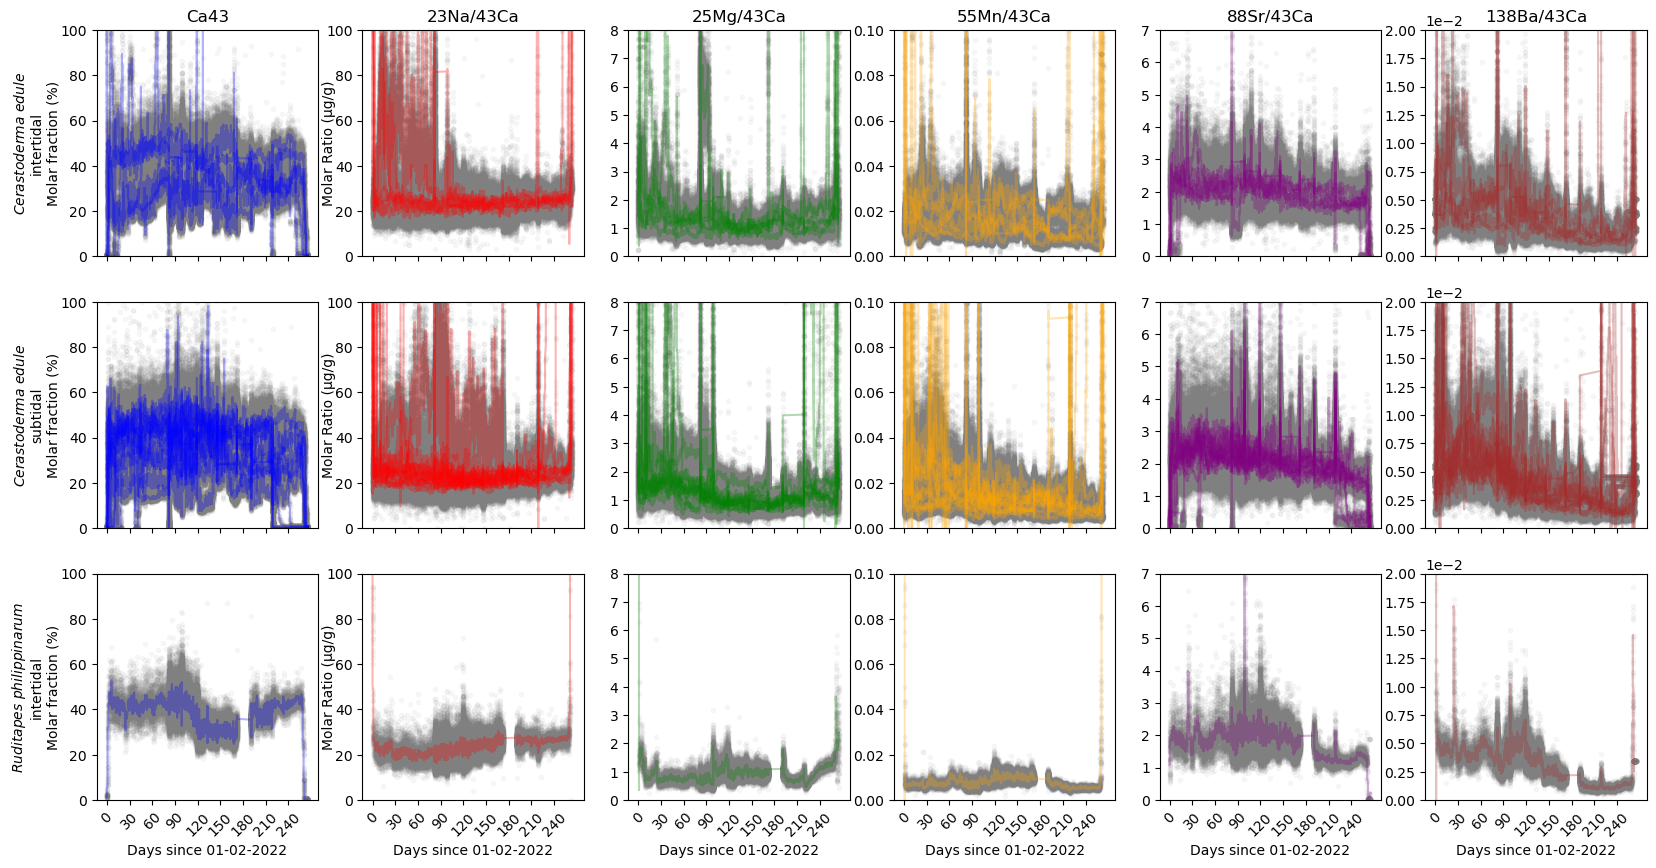

In [ ]:
# Prepare titles and axis values for the plots
element_columns = ['Ca43', '23Na/43Ca', '25Mg/43Ca', '55Mn/43Ca', '88Sr/43Ca', '138Ba/43Ca']
element_colors = {
    'Ca43': 'blue',
    '23Na/43Ca': 'red',
    '25Mg/43Ca': 'green',
    '55Mn/43Ca': 'orange',
    '88Sr/43Ca': 'purple',
    '138Ba/43Ca': 'brown'
}
element_max_values = {
    'Ca43': 100, # Set max value for Ca43 to 100% since it's a molar fraction
    '23Na/43Ca': 100,
    '25Mg/43Ca': 8,
    '55Mn/43Ca': 0.1,
    '88Sr/43Ca': 7,
    '138Ba/43Ca': 0.02
}

# Set multiplier to use with y-axes to make them more readable
fmt = ticker.ScalarFormatter()
fmt.set_powerlimits((-2, 3))  # Set power limits to avoid scientific notation for values between 10^-2 and 10^3

# Organize plot in a grid of 3 rows and 6 columns
fig, axs = plt.subplots(3, len(element_columns), figsize=(20, 10), sharex='col', sharey='col')

# Loop through each specimen and plot the element ratios against depth for each species and treatment
for i, element in enumerate(element_columns):
    for j, (species, treatment) in enumerate(all_data.groupby(['species', 'treatment'])):
        subset = treatment
        # print(species, subset.shape, i, j)
        for specimen in subset['specimen'].unique():
            specimen_subset = subset[subset['specimen'] == specimen]
            
            Time = specimen_subset['timing_1']  # Extract time vector
            # Convert date vector to days since start of the year for better plotting
            Time = pd.to_datetime(Time, errors='coerce')  # Convert to datetime, coerce errors to NaT
            Time = (Time - Time.min()).dt.days  # Convert to days since the earliest date

            el = specimen_subset[element].copy()  # Get the element ratio values for the current specimen
            median_value = el.median()
            el.fillna(median_value, inplace=True)
            el_filtered = signal.savgol_filter(el,
                           51, # window size used for filtering
                           2) # order of fitted polynomial
            # For Ca data, convert to mol%
            if element == 'Ca43':
                el = el / 10**6 * 100
                el_filtered = el_filtered / 10**6 * 100            
            axs[j, i].scatter(Time, el, label=f"{species} - {treatment}", alpha=0.05, color = "gray", marker = '.')
            axs[j, i].plot(Time, el_filtered, label=f"{species} - {treatment}", alpha=0.3, color = element_colors[element])
            axs[j, 1].set_ylabel('Molar Ratio (µg/g)', labelpad=-7)
    # Manually set left y-axis labels to indicate grouping
    axs[0, 0].set_ylabel('$\it{Cerastoderma}$ $\it{edule}$\nintertidal\nMolar fraction (%)', labelpad = 0)
    axs[1, 0].set_ylabel('$\it{Cerastoderma}$ $\it{edule}$\nsubtidal\nMolar fraction (%)', labelpad = 0)
    axs[2, 0].set_ylabel('$\it{Ruditapes}$ $\it{philippinarum}$\nintertidal\nMolar fraction (%)', labelpad = 0)
    axs[0, i].set_title(element)
    axs[j, i].set_ylim(0, element_max_values[element])  # Set y-axis limit based on predefined max values
    if element == '138Ba/43Ca':
        axs[j, i].yaxis.set_major_formatter(fmt)  # Apply the formatter to the y-axis of the Ba/Ca plot only
    axs[j, i].set_xlabel('Days since 01-02-2022')
    axs[j, i].set_xticks(np.arange(0, Time.max() + 1, 30))  # Set x-ticks every 30 days
    axs[j, i].tick_params(axis='x', rotation=45)

## Plot all elemental records against date, organized by treatment and species

<>:52: SyntaxWarning: invalid escape sequence '\i'
<>:53: SyntaxWarning: invalid escape sequence '\i'
<>:54: SyntaxWarning: invalid escape sequence '\i'
<>:52: SyntaxWarning: invalid escape sequence '\i'
<>:53: SyntaxWarning: invalid escape sequence '\i'
<>:54: SyntaxWarning: invalid escape sequence '\i'
C:\Users\nwi213\AppData\Local\Temp\ipykernel_33312\587881470.py:52: SyntaxWarning: invalid escape sequence '\i'
  axs[0, 0].set_ylabel('$\it{Cerastoderma}$ $\it{edule}$\nintertidal\nMolar fraction (%)', labelpad = 0)
C:\Users\nwi213\AppData\Local\Temp\ipykernel_33312\587881470.py:53: SyntaxWarning: invalid escape sequence '\i'
  axs[1, 0].set_ylabel('$\it{Cerastoderma}$ $\it{edule}$\nsubtidal\nMolar fraction (%)', labelpad = 0)
C:\Users\nwi213\AppData\Local\Temp\ipykernel_33312\587881470.py:54: SyntaxWarning: invalid escape sequence '\i'
  axs[2, 0].set_ylabel('$\it{Ruditapes}$ $\it{philippinarum}$\nintertidal\nMolar fraction (%)', labelpad = 0)


42642   2022-10-25 10:00:00
42643   2022-10-25 09:24:01
42644   2022-10-25 08:48:02
42645   2022-10-25 08:12:03
42646   2022-10-25 07:36:04
42647   2022-10-25 07:00:05
42648   2022-10-25 06:24:06
42649   2022-10-25 05:48:07
42650   2022-10-25 05:12:08
42651   2022-10-25 04:36:09
Name: timing_1, dtype: datetime64[ns]
71201   2022-10-25 10:00:00
71202   2022-10-25 09:08:00
71203   2022-10-25 08:17:00
71204   2022-10-25 07:26:00
71205   2022-10-25 06:35:00
71206   2022-10-25 05:44:00
71207   2022-10-25 04:52:00
71208   2022-10-25 04:01:00
71209   2022-10-25 03:10:00
71210   2022-10-25 02:19:00
Name: timing_1, dtype: datetime64[ns]
204691   2022-10-25 10:00:00
204692   2022-10-25 09:26:07
204693   2022-10-25 08:52:14
204694   2022-10-25 08:18:21
204695   2022-10-25 07:44:29
204696   2022-10-25 07:10:36
204697   2022-10-25 06:36:43
204698   2022-10-25 06:02:50
204699   2022-10-25 05:28:57
204700   2022-10-25 04:55:04
Name: timing_1, dtype: datetime64[ns]
271873   2022-10-25 10:00:00
271874 

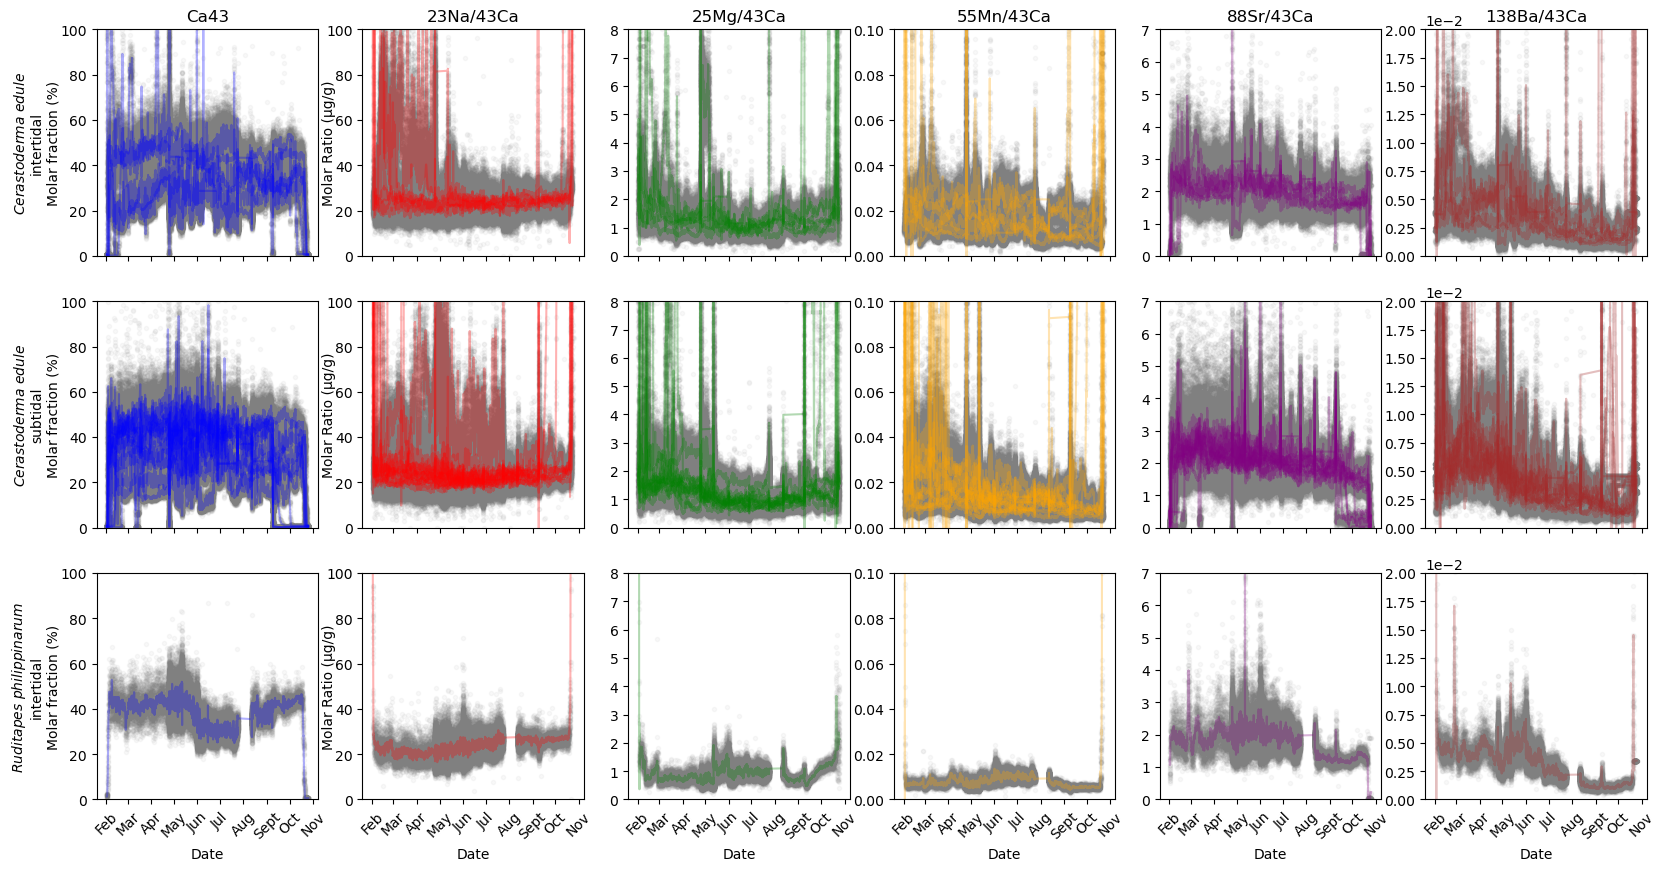

In [15]:
# Prepare titles and axis values for the plots
element_columns = ['Ca43', '23Na/43Ca', '25Mg/43Ca', '55Mn/43Ca', '88Sr/43Ca', '138Ba/43Ca']
element_colors = {
    'Ca43': 'blue',
    '23Na/43Ca': 'red',
    '25Mg/43Ca': 'green',
    '55Mn/43Ca': 'orange',
    '88Sr/43Ca': 'purple',
    '138Ba/43Ca': 'brown'
}
element_max_values = {
    'Ca43': 100, # Set max value for Ca43 to 100% since it's a molar fraction
    '23Na/43Ca': 100,
    '25Mg/43Ca': 8,
    '55Mn/43Ca': 0.1,
    '88Sr/43Ca': 7,
    '138Ba/43Ca': 0.02
}

# Set multiplier to use with y-axes to make them more readable
fmt = ticker.ScalarFormatter()
fmt.set_powerlimits((-2, 3))  # Set power limits to avoid scientific notation for values between 10^-2 and 10^3

# Organize plot in a grid of 3 rows and 6 columns
fig, axs = plt.subplots(3, len(element_columns), figsize=(20, 10), sharex='col', sharey='col')

# Loop through each specimen and plot the element ratios against depth for each species and treatment
for i, element in enumerate(element_columns):
    for j, (species, treatment) in enumerate(all_data.groupby(['species', 'treatment'])):
        subset = treatment
        # print(species, subset.shape, i, j)
        for specimen in subset['specimen'].unique():
            specimen_subset = subset[subset['specimen'] == specimen]
            
            Time = pd.to_datetime(specimen_subset['timing_1'], errors='coerce')  # Extract time vector
            print(Time[0:10])

            el = specimen_subset[element].copy()  # Get the element ratio values for the current specimen
            median_value = el.median()
            el.fillna(median_value, inplace=True)
            el_filtered = signal.savgol_filter(el,
                           51, # window size used for filtering
                           2) # order of fitted polynomial
            # For Ca data, convert to mol%
            if element == 'Ca43':
                el = el / 10**6 * 100
                el_filtered = el_filtered / 10**6 * 100            
            axs[j, i].scatter(Time, el, label=f"{species} - {treatment}", alpha=0.05, color = "gray", marker = '.')
            axs[j, i].plot(Time, el_filtered, label=f"{species} - {treatment}", alpha=0.3, color = element_colors[element])
            axs[j, 1].set_ylabel('Molar Ratio (µg/g)', labelpad=-7)
    # Manually set left y-axis labels to indicate grouping
    axs[0, 0].set_ylabel('$\it{Cerastoderma}$ $\it{edule}$\nintertidal\nMolar fraction (%)', labelpad = 0)
    axs[1, 0].set_ylabel('$\it{Cerastoderma}$ $\it{edule}$\nsubtidal\nMolar fraction (%)', labelpad = 0)
    axs[2, 0].set_ylabel('$\it{Ruditapes}$ $\it{philippinarum}$\nintertidal\nMolar fraction (%)', labelpad = 0)
    axs[0, i].set_title(element)
    axs[j, i].set_ylim(0, element_max_values[element])  # Set y-axis limit based on predefined max values
    if element == '138Ba/43Ca':
        axs[j, i].yaxis.set_major_formatter(fmt)  # Apply the formatter to the y-axis of the Ba/Ca plot only
    axs[j, i].set_xlabel('Date')
    axs[j, i].tick_params(axis='x', rotation=45)
    axs[j, i].xaxis.set_major_locator(mdates.MonthLocator())  # Set x-ticks to be at the start of each month
    axs[j, i].xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Format x-ticks as day and month

## Plot elemental profiles of sections surrounding peaks

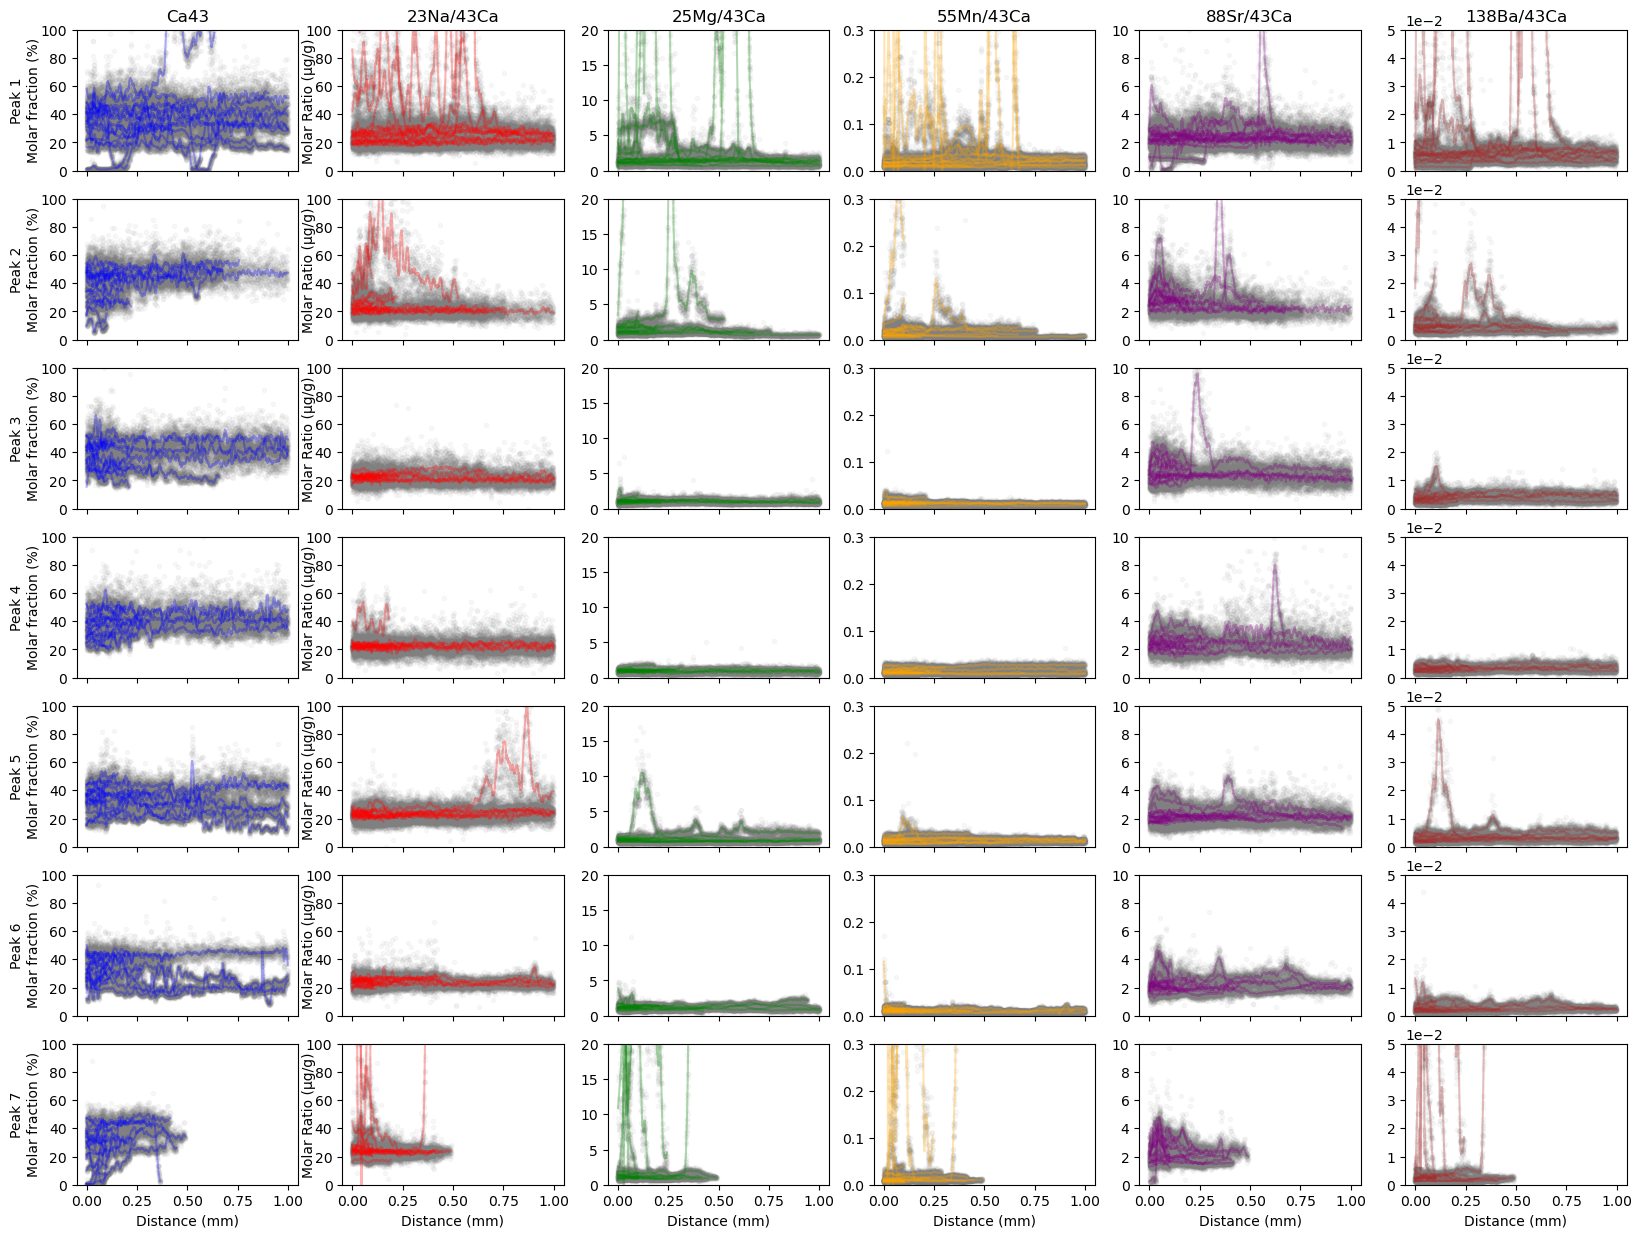

In [30]:
# FIXME: Expand horizontal axis to +/1 0.5 mm around the peak centers to better visualize the spikes

# Prepare titles and axis values for the plots
element_columns = ['Ca43', '23Na/43Ca', '25Mg/43Ca', '55Mn/43Ca', '88Sr/43Ca', '138Ba/43Ca']
element_colors = {
    'Ca43': 'blue',
    '23Na/43Ca': 'red',
    '25Mg/43Ca': 'green',
    '55Mn/43Ca': 'orange',
    '88Sr/43Ca': 'purple',
    '138Ba/43Ca': 'brown'
}
element_max_values = {
    'Ca43': 100, # Set max value for Ca43 to 100% since it's a molar fraction
    '23Na/43Ca': 100,
    '25Mg/43Ca': 20,
    '55Mn/43Ca': 0.3,
    '88Sr/43Ca': 10,
    '138Ba/43Ca': 0.05
}

# Set multiplier to use with y-axes to make them more readable
fmt = ticker.ScalarFormatter()
fmt.set_powerlimits((-2, 3))  # Set power limits to avoid scientific notation for values between 10^-2 and 10^3

# Organize plot in a grid of 7 rows and 6 columns
fig, axs = plt.subplots(7, len(element_columns), figsize=(20, 15), sharex='col', sharey='col')

# Loop through each specimen and plot the element ratios against distance for each peak
for i, element in enumerate(element_columns):
    for j, (peak, subset) in enumerate(all_data.groupby(['peakID_1'])):
        if j > 7:  # Only plot the 7 peaks (no intervals)
            # print(peak, subset.shape, i, j)
            for specimen in subset['specimen'].unique():
                specimen_subset = subset[subset['specimen'] == specimen]
                D = (specimen_subset['depth'] - specimen_subset['depth'].min()) / 1000  # Convert distance to mm
                el = specimen_subset[element].copy()  # Get the element ratio values for the current specimen
                median_value = el.median()
                el.fillna(median_value, inplace=True)
                el_filtered = signal.savgol_filter(el,
                               51, # window size used for filtering
                               2) # order of fitted polynomial
                # For Ca data, convert to mol%
                if element == 'Ca43':
                    el = el / 10**6 * 100
                    el_filtered = el_filtered / 10**6 * 100            
                axs[j - 8, i].scatter(D, el, label=f"{species} - {treatment}", alpha=0.05, color = "gray", marker = '.')
                axs[j - 8, i].plot(D, el_filtered, label=f"{species} - {treatment}", alpha=0.3, color = element_colors[element])
                axs[j - 8, 1].set_ylabel('Molar Ratio (µg/g)', labelpad=-7)
    axs[0, i].set_title(element)
    axs[j - 8, i].set_ylim(0, element_max_values[element])  # Set y-axis limit based on predefined max values
    if element == '138Ba/43Ca':
        axs[j - 8, i].yaxis.set_major_formatter(fmt)  # Apply the formatter to the y-axis of the Ba/Ca plot only
    axs[j - 8, i].set_xlabel('Distance (mm)')

    # Manually set left y-axis labels to indicate peaks
    axs[0, 0].set_ylabel('Peak 1\nMolar fraction (%)', labelpad = 0)
    axs[1, 0].set_ylabel('Peak 2\nMolar fraction (%)', labelpad = 0)
    axs[2, 0].set_ylabel('Peak 3\nMolar fraction (%)', labelpad = 0)
    axs[3, 0].set_ylabel('Peak 4\nMolar fraction (%)', labelpad = 0)
    axs[4, 0].set_ylabel('Peak 5\nMolar fraction (%)', labelpad = 0)
    axs[5, 0].set_ylabel('Peak 6\nMolar fraction (%)', labelpad = 0)
    axs[6, 0].set_ylabel('Peak 7\nMolar fraction (%)', labelpad = 0)